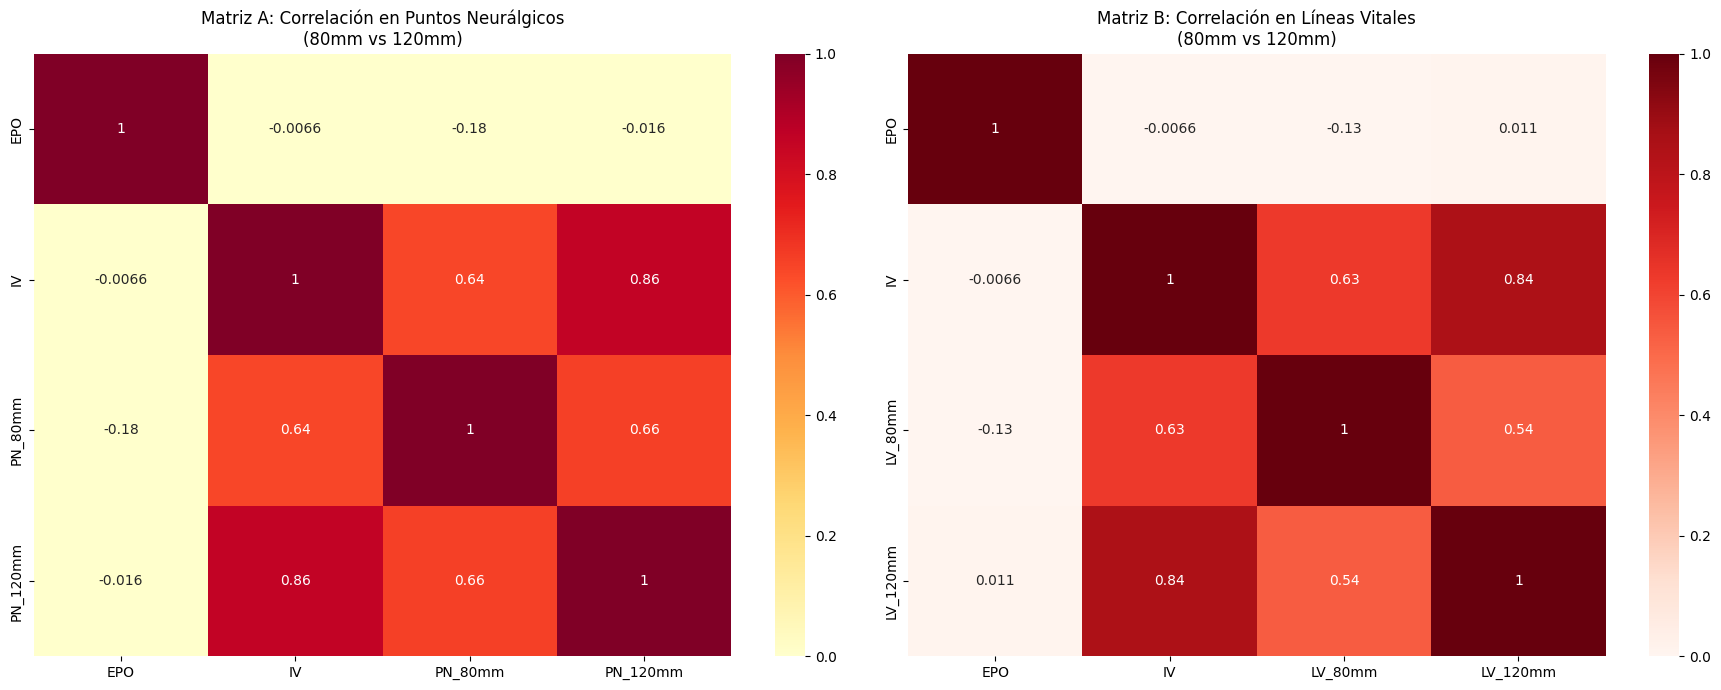

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. GENERACIÓN DE ESCENARIO SINTÉTICO
def generar_datos_edan(n_sectores=50):
    np.random.seed(42)

    # EPO: Probabilidad (1: Rara, 5: Frecuente)
    # IV: Índice de Vulnerabilidad (1: Resiliente, 5: Crítico)
    epo = np.random.randint(1, 6, n_sectores)
    iv = np.random.randint(1, 6, n_sectores)

    # Impacto a 80 mm/h (Escenario Base)
    # El daño es bajo y poco dependiente de la vulnerabilidad porque el sistema aguanta.
    pn_80 = np.clip(np.round(0.3 * iv + np.random.normal(1, 0.4, n_sectores)), 1, 5)
    lv_80 = np.clip(np.round(0.2 * iv + np.random.normal(1, 0.4, n_sectores)), 1, 5)

    # Impacto a 120 mm/h (Escenario Potenciado)
    # El daño "dispara" su correlación con el IV. A mayor IV, el colapso es casi seguro (5).
    pn_120 = np.clip(np.round(0.8 * iv + np.random.normal(2, 0.6, n_sectores)), 1, 5)
    lv_120 = np.clip(np.round(0.9 * iv + np.random.normal(2, 0.6, n_sectores)), 1, 5)

    return pd.DataFrame({
        'EPO': epo, 'IV': iv,
        'PN_80mm': pn_80, 'PN_120mm': pn_120,
        'LV_80mm': lv_80, 'LV_120mm': lv_120
    })

df = generar_datos_edan()

# 2. CÁLCULO Y VISUALIZACIÓN DE MATRICES
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz A: Potenciación en Puntos Neurálgicos
sns.heatmap(df[['EPO', 'IV', 'PN_80mm', 'PN_120mm']].corr(),
            annot=True, cmap='YlOrRd', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Matriz A: Correlación en Puntos Neurálgicos\n(80mm vs 120mm)')

# Matriz B: Potenciación en Líneas Vitales
sns.heatmap(df[['EPO', 'IV', 'LV_80mm', 'LV_120mm']].corr(),
            annot=True, cmap='Reds', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Matriz B: Correlación en Líneas Vitales\n(80mm vs 120mm)')

plt.tight_layout()
plt.show()